If I can reliably determine the mapping between FIT and JPG image data, then I can use this mapping to imputate the real brightness of the older JPGs, and possibly calibrate to correct for the data change.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from glob import glob
fit_images = sorted(glob("../../images/AllSkyImages/2026-03/*.FIT"))
jpg_images = sorted(glob("../../images/AllSkyImages/2026-03/*.JPG"))

fit_set = set(fit_images)
image_pairs = []
for jpg_filepath in jpg_images:
    fit_filepath = jpg_filepath.replace(".JPG", ".FIT")
    if fit_filepath in fit_set:
        image_pairs.append((jpg_filepath, fit_filepath))

len(image_pairs)

6863

In [4]:
image_pairs[1]

('../../images/AllSkyImages/2026-03/AllSkyImage000418696.JPG',
 '../../images/AllSkyImages/2026-03/AllSkyImage000418696.FIT')

In [5]:
from astropy.io import fits
from astropy.io.fits.hdu.image import PrimaryHDU
hdu: PrimaryHDU = fits.open(image_pairs[0][1])[0]
header = hdu.header
dict(header)

{'SIMPLE': True,
 'BITPIX': 16,
 'NAXIS': 2,
 'NAXIS1': 640,
 'NAXIS2': 480,
 'INSTRUME': 'SBIG AllSky-340',
 'DATE-OBS': '2026-03-20T23:44:20.734',
 'BSCALE': 1.0,
 'BZERO': 32768.0,
 'EXPTIME': 0.0483,
 'CBLACK': 1558,
 'CWHITE': 13762}

Detour: Let's plot some of the header values

In [6]:
def get_fit_header(filename):
    hdu: PrimaryHDU = fits.open(filename)[0]
    header = hdu.header
    return dict(header)


headers_df = pd.DataFrame.from_records(
    pd.Series(np.array(image_pairs)[:, 1]).apply(get_fit_header)
)
headers_df["DATE-OBS"] = pd.to_datetime(headers_df["DATE-OBS"])
headers_df

,SIMPLE,BITPIX,NAXIS,NAXIS1,NAXIS2,INSTRUME,DATE-OBS,BSCALE,BZERO,EXPTIME,CBLACK,CWHITE
0,True,16,2,640,480,SBIG AllSky-340,2026-03-20 23:44:20.734,1.0,32768.0,0.0483,1558,13762
1,True,16,2,640,480,SBIG AllSky-340,2026-03-20 23:45:30.059,1.0,32768.0,0.0702,1524,12874
2,True,16,2,640,480,SBIG AllSky-340,2026-03-20 23:45:49.363,1.0,32768.0,0.1091,1811,19055
3,True,16,2,640,480,SBIG AllSky-340,2026-03-20 23:46:19.437,1.0,32768.0,0.1091,1747,18371
4,True,16,2,640,480,SBIG AllSky-340,2026-03-20 23:46:49.505,1.0,32768.0,0.1091,1695,17963
...,...,...,...,...,...,...,...,...,...,...,...,...
6858,True,16,2,640,480,SBIG AllSky-340,2026-03-27 02:37:50.253,1.0,32768.0,9.3215,1793,19810
6859,True,16,2,640,480,SBIG AllSky-340,2026-03-27 02:38:49.109,1.0,32768.0,9.3215,1784,18921
6860,True,16,2,640,480,SBIG AllSky-340,2026-03-27 02:43:56.466,1.0,32768.0,9.3215,2115,27824
6861,True,16,2,640,480,SBIG AllSky-340,2026-03-27 02:45:20.036,1.0,32768.0,3.3501,1361,10656


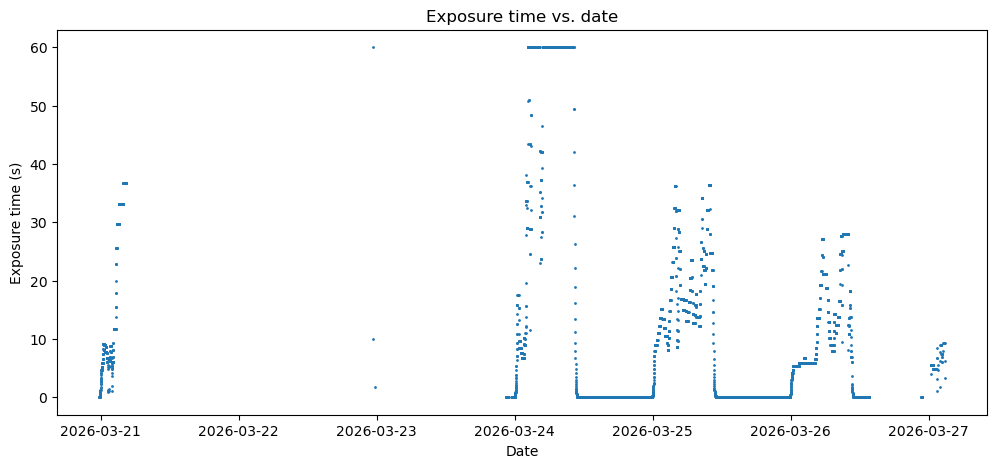

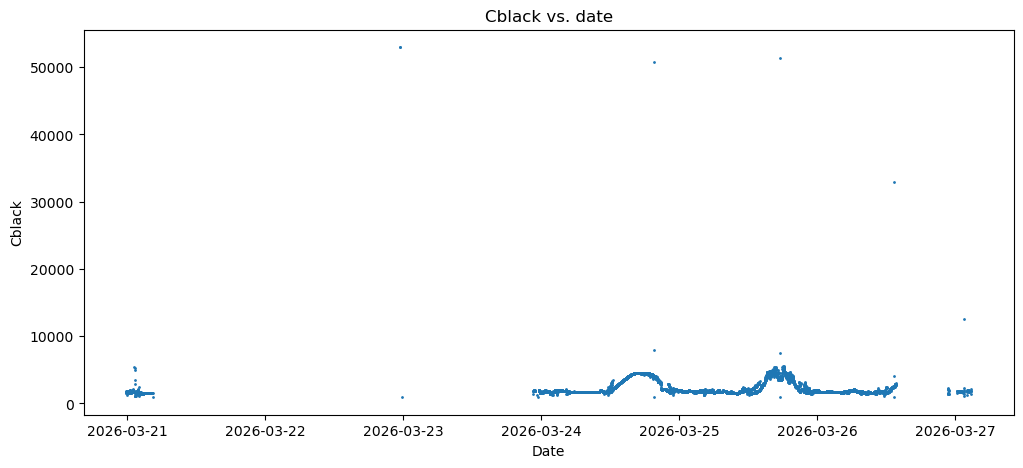

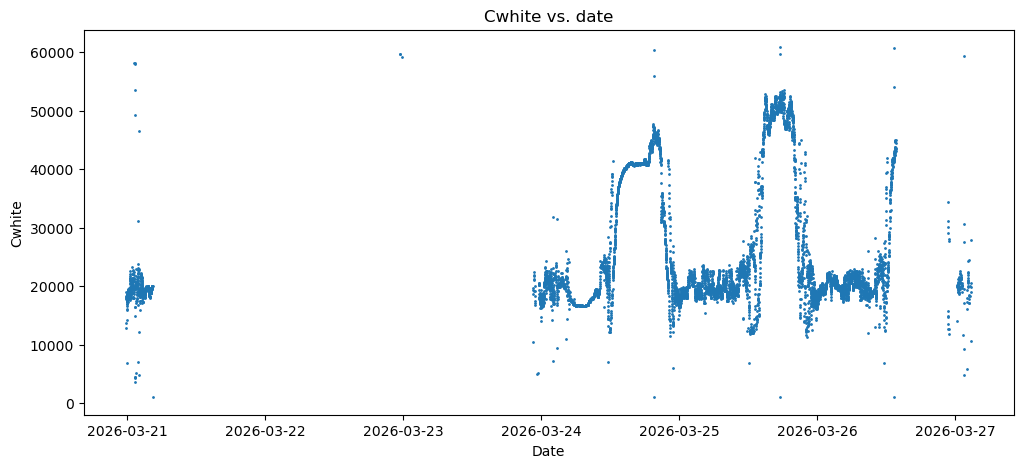

In [7]:
def plot_exposure_time(df):
    plt.figure(figsize=(12, 5))
    plt.scatter(df["DATE-OBS"], df["EXPTIME"], s=1)
    plt.xlabel("Date")
    plt.ylabel("Exposure time (s)")
    plt.title("Exposure time vs. date")

def plot_cblack(df):
    plt.figure(figsize=(12, 5))
    plt.scatter(df["DATE-OBS"], df["CBLACK"], s=1)
    plt.xlabel("Date")
    plt.ylabel("Cblack")
    plt.title("Cblack vs. date")

def plot_cwhite(df):
    plt.figure(figsize=(12, 5))
    plt.scatter(df["DATE-OBS"], df["CWHITE"], s=1)
    plt.xlabel("Date")
    plt.ylabel("Cwhite")
    plt.title("Cwhite vs. date")

plot_exposure_time(headers_df)
plot_cblack(headers_df)
plot_cwhite(headers_df)


During sunlight, the CBLACK and CWHITE values were bumped upward, adjusting the window upward so that the JPG would map values still.

CBLACK remains nearly constant outside of these periods, near zero, whereas CWHITE fluctuates from frame to frame.

This implies that a single correction factor will not be sufficient.

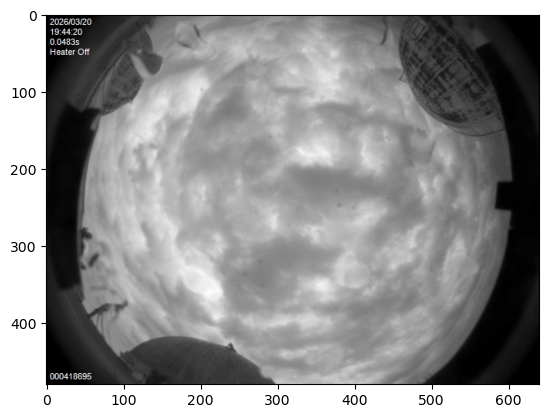

In [8]:
plt.imshow(plt.imread(image_pairs[0][0]))

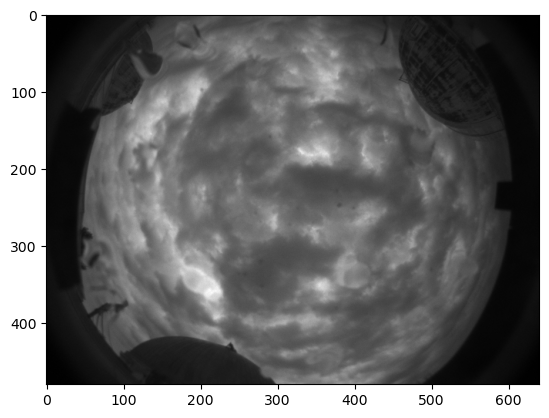

In [9]:
plt.imshow(fits.getdata(image_pairs[0][1]), cmap="gray")

In [10]:
jpg_data = plt.imread(image_pairs[0][0])
fits_data = fits.getdata(image_pairs[0][1])
jpg_data.shape, fits_data.shape

((480, 640, 3), (480, 640))

In [11]:
jpg_redchannel = jpg_data[:,:,0]
(
    (jpg_redchannel.shape, jpg_redchannel.dtype),
    (fits_data.shape, fits_data.dtype),
)

(((480, 640), dtype('uint8')), ((480, 640), dtype('uint16')))

Obviously we already knew that the FIT file has double the bit depth, but I guess it's nice to confirm it.

In [12]:
assert jpg_redchannel.shape == fits_data.shape
shape = jpg_redchannel.shape
{
    'jpg_min': jpg_redchannel.min(),
    'jpg_min_loc': np.unravel_index(jpg_redchannel.argmin(), shape),
    'fits_min': fits_data.min(),
    'fits_min_loc': np.unravel_index(fits_data.argmin(), shape),
    'jpg_val_at_fits_min': jpg_redchannel[
        np.unravel_index(fits_data.argmin(), shape)
    ],
    'fits_val_at_jpg_min': fits_data[
        np.unravel_index(jpg_redchannel.argmin(), shape)
    ]
}

{'jpg_min': np.uint8(0),
 'jpg_min_loc': (np.int64(0), np.int64(5)),
 'fits_min': np.uint16(1006),
 'fits_min_loc': (np.int64(466), np.int64(13)),
 'jpg_val_at_fits_min': np.uint8(254),
 'fits_val_at_jpg_min': np.uint16(1200)}

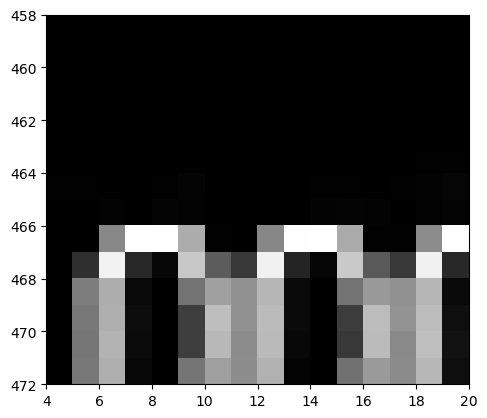

In [13]:
plt.imshow(jpg_redchannel[458:472, 4:20], extent=(4,20,472,458), cmap="gray")

The image above shows that the min value in the fits is down by the filename is burned into the JPG pixels. Clearly, attempting to equalize would need to account for masking out the location where text would be in both images.

In [14]:
y, x = np.ogrid[:480, :640]
mask_2d = ((x - 320) ** 2 + (y - 240) ** 2 > 200 ** 2)

def mask_image(image) -> np.ma.MaskedArray:
    if image.ndim == 2:
        out = np.ma.array(image, mask=mask_2d)
    elif image.ndim == 3:
        mask_3d = np.broadcast_to(mask_2d[:, :, None], image.shape)
        out = np.ma.array(image, mask=mask_3d)
    else:
        raise ValueError(f"Unsupported image shape: {image.shape}")
    return out[40:440,120:520]


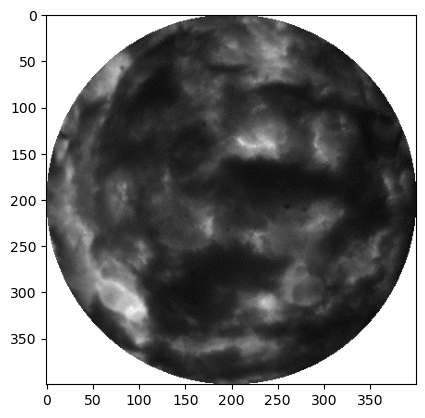

In [15]:
masked_fits = mask_image(fits_data)
masked_jpg = mask_image(jpg_redchannel)
_ = plt.imshow((masked_fits / masked_jpg), cmap="gray")

In [16]:
# Taking (458, 13) as the dark-coordinate just to work around the issue for now
darkest_jpg_val = jpg_redchannel[(458, 13)]
brightest_fits_val_loc = fits_data.argmax()
brightest_jpg_val = jpg_redchannel[np.unravel_index(brightest_fits_val_loc, shape)]

(np.float64(56.46514497223936),
 np.float64(240.82911782850093),
 np.float64(27.15634656510609),
 np.uint8(111),
 np.uint8(254),
 np.float64(24.4778176121815))

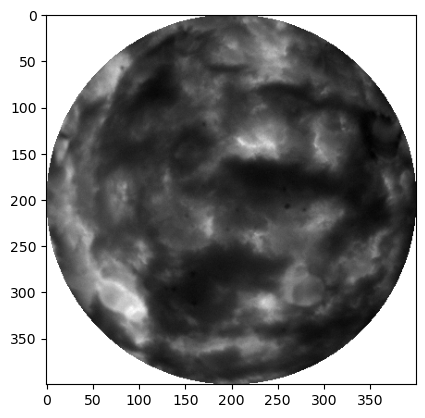

In [17]:

factor = fits_data.max() / brightest_jpg_val

output = ((masked_fits - fits_data.min()) / factor)
_ = plt.imshow(output, cmap="gray")
(
    output.min(), output.max(), output.std(),
    masked_jpg.min(), masked_jpg.max(), masked_jpg.std()
)

This proves a single multiplicative factor cannot fix this. Possible we can use a linear one still.

In [18]:
header = fits.getheader(image_pairs[0][1])
header["CBLACK"], header["CWHITE"]

(1558, 13762)

In [19]:
(
    masked_jpg.argmin(),
    masked_jpg.argmax(),
    masked_fits.argmin(),
    masked_fits.argmax(),
)

(np.int64(53547), np.int64(127292), np.int64(61552), np.int64(128494))

The precise indices of the mins and maxes are not identical. Shame.

In [20]:
factors = (masked_fits / masked_jpg)

(
    factors.min(),
    factors.max(),
    factors.mean(),
    factors.std(),
)

(np.float64(52.583333333333336),
 np.float64(90.05555555555556),
 np.float64(61.0064710900282),
 np.float64(5.058225346138875))

There's nothing here playing with the math that would allow remapping this well. It might be a curve or something else.

Using `stored_value = linear_value ^ (1 / 2.2)` transfer function.

To get `linear_value` back, I need to `pow(stored_value, 1 / 2.2)`.

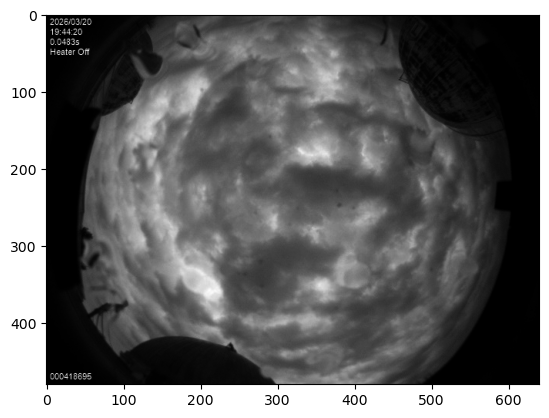

In [21]:
# to get the linear value back I need to pow(stored
linear_jpg = np.float_power(jpg_redchannel, 2.2)
_ = plt.imshow(linear_jpg, cmap="gray")

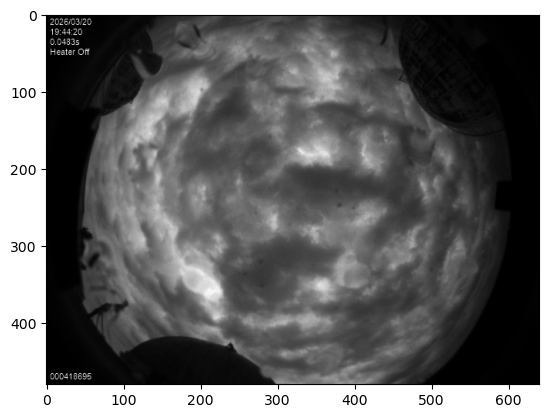

In [22]:
_ = plt.imshow(masked_fits - (mask_image(linear_jpg)), cmap="gray")
from PIL import Image
# JPG is 8-bit srgb, FIT is 16-bit linear.
# we want to properly convert the `jpg_data` to linear, starting with .fromarray
img = Image.fromarray(jpg_data.astype(np.uint8), mode="RGB")

# Back to ndarray in float, normalized to [0, 1]
srgb = np.asarray(img, dtype=np.float32) / 255.0

# sRGB -> linear light
linear_jpg = np.where(
    srgb <= 0.04045,
    srgb / 12.92,
    ((srgb + 0.055) / 1.055) ** 2.4,
)
linear_jpg_red = linear_jpg[:, :, 0]
plt.imshow(linear_jpg_red, cmap='gray')

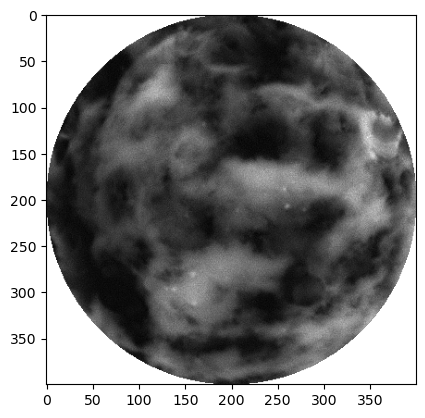

In [23]:
_ = plt.imshow((masked_fits / mask_image(linear_jpg_red)), cmap="gray")

In [24]:
def srgb_to_linear(arr):
    arr = np.asarray(arr, dtype=np.float32) / 255.0
    return np.where(
        arr <= 0.04045,
        arr / 12.92,
        ((arr + 0.055) / 1.055) ** 2.4,
    )

jpg_linear = srgb_to_linear(jpg_data)
jpg_red = jpg_linear[:, :, 0]

mask = ~((x >= 0) & (x < 80) & (y >= 0) & (y < 80))
mask &= ~((x >= 0) & (x < 80) & (y >= 450) & (y < 480))

valid = ~mask
fits_vals = fits_data[valid].astype(np.float32)
jpg_vals = jpg_red[valid].astype(np.float32)

# Solve jpg ≈ a * fits + b
A = np.column_stack([fits_vals, np.ones_like(fits_vals)])
a, b = np.linalg.lstsq(A, jpg_vals, rcond=None)[0]

# Apply transform
jpg_fit_est = a * fits_data.astype(np.float32) + b
jpg_fit_est = np.clip(jpg_fit_est, 0, 1)

a, b

(np.float32(-3.3022454e-05), np.float32(0.13781708))

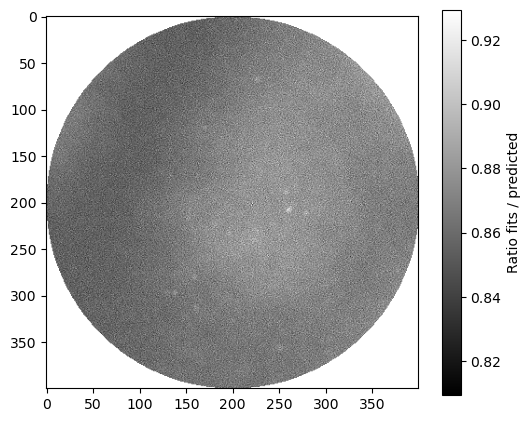

In [75]:
jpg_path, fit_path = image_pairs[3600]
test_image = plt.imread(jpg_path)
test_red = srgb_to_linear(test_image)[:,:,0]
test_fits = fits.getdata(fit_path).astype(np.float32)

predicted_fits = (test_red + b) / -a


fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mask_image(test_fits) / mask_image(predicted_fits), cmap="gray")
fig.colorbar(im, ax=ax, label="Ratio fits / predicted")
# fig.tight_layout()

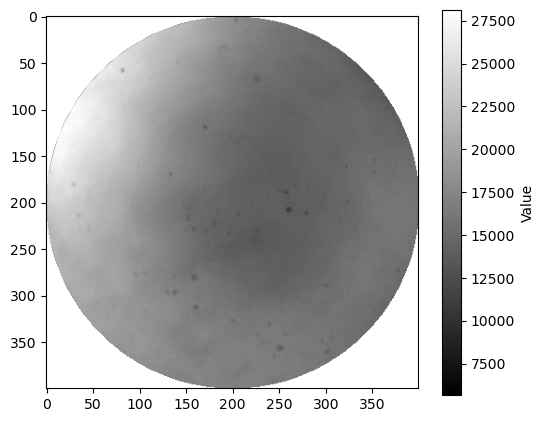

In [72]:
# plt.imshow(mask_image(predicted_fits), cmap="gray")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    mask_image(predicted_fits)
, cmap="gray")
fig.colorbar(im, ax=ax, label="Value")

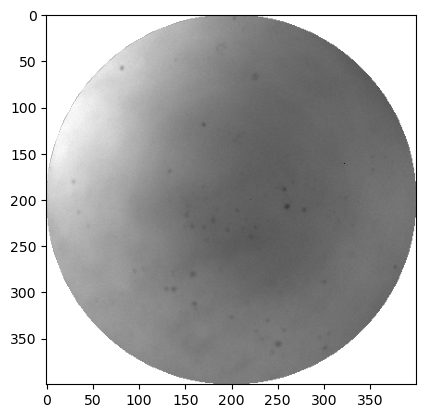

In [66]:
plt.imshow(mask_image(test_fits), cmap='gray')

It looks like with the affine transform, we might be able to recreate approximate FIT data

In [67]:
np.min(predicted_fits), np.max(predicted_fits)

(np.float32(4173.4355), np.float32(34455.863))

It would appear that although the transform creates a relatively uniform... hmm wait

In [68]:
fits.getheader(fit_path)

SIMPLE  =                    T                                                  
BITPIX  =                   16                                                  
NAXIS   =                    2                                                  
NAXIS1  =                  640                                                  
NAXIS2  =                  480                                                  
INSTRUME= 'SBIG AllSky-340'                                                     
DATE-OBS= '2026-03-25T07:58:06.715'                                             
BSCALE  = +1.000000000000E+000                                                  
BZERO   = +3.276800000000E+004                                                  
EXPTIME = +1.374140000000E+001                                                  
CBLACK  =                 1873                                                  
CWHITE  =                20163                                                  

Okay yeah so there the CBLACK and CWHITE don't even match the offsets I'm seeing :(

We can see for sure that one singular fit isn't able to get us reliably close to `predicted_fits ~= fits_data`